# Medical Insurance Cost Prediction - End-to-End Regression
### Teaching Notebook

> **Dataset:** Medical Cost Personal Dataset · Kaggle (mirichoi0218/insurance)  
> **Target:** `charges` - annual medical costs billed by insurance (USD)  
> **Rows:** 1,338 · **Features:** 6 · **Missing values:** 0

---
**Notebook Structure:**
1. Setup & Data Loading
2. Column Explanation
3. Univariate Analysis
4. Bivariate Analysis
5. Data Preparation & Feature Engineering
6. Custom Feature Creation
7. Modeling - Baseline to Advanced
8. Hyperparameter Tuning
9. Final Evaluation & Summary


### 🏥 Scenario: The Underpricing Dilemma
> Imagine you are a Data Scientist at a major health insurance company. Your company sets annual premiums based on customer profiles. If you price premiums **too high**, healthy customers will leave for competitors. If you price them **too low**, sick customers will claim more than they pay in premiums, bankrupting the company.
>
> **Goal:** Build a model that accurately predicts expected medical costs so the business can price competitively while remaining profitable.

## 1. Setup & Data Loading

In [1]:
# Split the dataset into 80% training data and 20% test data
# Use 'stratify' on the 'smoker' column so both sets have the same proportion of smokers
# Uncomment to install if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost scipy

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.dummy import DummyRegressor
from scipy.stats import uniform, randint

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed. Run: pip install xgboost')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
PALETTE = {'no': '#378ADD', 'yes': '#D85A30'}
print('All imports successful')


All imports successful


In [2]:
# Download the dataset from GitHub if not already present
# Read the data into a Pandas DataFrame
import urllib.request, os

URL = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
if not os.path.exists('insurance.csv'):
    urllib.request.urlretrieve(URL, 'insurance.csv')
    print('Downloaded insurance.csv')

df = pd.read_csv('insurance.csv')
print(f'Shape: {df.shape}')
df.head()


Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# View the structure of the dataset (columns, non-null counts, datatypes)
# View descriptive statistics for numeric columns
print(df.info())
print('\nDescriptive stats:')
df.describe().round(2)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Descriptive stats:


,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


### Quick data quality and summary findings

**Data structure**
- **Rows**: 1,338 individuals. **Columns**: 7 (`age`, `sex`, `bmi`, `children`, `smoker`, `region`, `charges`).
- **Types**:
  - Numeric: `age` (int), `bmi` (float), `children` (int), `charges` (float).
  - Categorical (string): `sex`, `smoker`, `region`.

**Data quality**
- **Missing values**: 0 across all columns ⇒ no imputation needed.
- **Duplicate rows**: 1 duplicate ⇒ dataset is almost fully unique. (We can drop the duplicate if we want a perfectly clean training set.)

**Descriptive statistics (numeric columns)**
- **Age**:
  - Range: **18–64** years, median ≈ **39**, mean ≈ **39.2**.
  - Good spread across adult ages ⇒ model will learn age effects reasonably well.
- **BMI**:
  - Mean ≈ **30.7**, std ≈ **6.1** ⇒ on average, slightly **overweight/obese** population.
  - Range: **16–53** ⇒ we do see very low and very high BMI values.
- **Children**:
  - Median = **1**, 75% of people have **≤ 2 children**, max = **5**.
  - Many individuals have **0 children**, so this is a sparse but important count feature.
- **Charges**:
  - Mean ≈ **$13.3k**, median ≈ **$9.4k** ⇒ **right‑skewed** with a heavy upper tail.
  - Range: **$1.1k–$63.8k**; 75th percentile ≈ **$16.6k**.
  - This skew is why we later model **log(charges)** instead of raw dollars.

**Categorical distributions**
- **Smoker**:
  - `no`: 1,064, `yes`: 274 ⇒ majority are non‑smokers, but smokers are a sizeable high‑risk subgroup.
- **Region**:
  - Fairly balanced across **southeast, southwest, northwest, northeast** (each ≈ 1/4 of the data), so region effects can be estimated without severe imbalance.

> Overall, the dataset is **small but clean**, with **no missing values**, a single duplicate, and clear signals in `age`, `bmi`, `smoker`, and `charges` that justify the later feature engineering and log‑regression modeling.

In [4]:
# Check for duplicate rows and missing values
# Look at the distribution for categorical columns
print(f'Duplicate rows  : {df.duplicated().sum()}')
print(f'Missing values  : {df.isnull().sum().sum()}')
print(f'\nValue counts - smoker\n{df["smoker"].value_counts()}')
print(f'\nValue counts - region\n{df["region"].value_counts()}')


Duplicate rows  : 1
Missing values  : 0

Value counts - smoker
no     1064
yes     274
Name: smoker, dtype: int64

Value counts - region
southeast    364
southwest    325
northwest    325
northeast    324
Name: region, dtype: int64


In [5]:
# Define the columns as lists to make it easier to work with them later
NUM_COLS = ['age', 'bmi', 'children']
CAT_COLS = ['sex', 'smoker', 'region']
TARGET   = 'charges'

print('Numeric features  :', NUM_COLS)
print('Categorical feats :', CAT_COLS)
print('Target            :', TARGET)


Numeric features  : ['age', 'bmi', 'children']
Categorical feats : ['sex', 'smoker', 'region']
Target            : charges


## 3. Univariate Analysis

For each variable: **What is the distribution? Is it skewed? Are there outliers?**  
For the target: **Does it satisfy linear regression assumptions?**


### ❓ Q&A: Why do we care about distribution shapes before modeling?
**Q:** Can't ML models just learn the patterns anyway? Why look at histograms manually?

**Answer:** Visualizing distributions is critical because:
1. **We find thresholds:** Seeing that BMI clusters near 30 helps us identify cutoffs (like obesity at >= 30) to create new flag features.
2. **We catch errors:** If `age` had values like 999 or -5, we'd spot them here and filter them before the model learns garbage.
3. **We decide on transforms:** Realizing a variable is right-skewed tells us we might need to apply a log-transform for linear models to work correctly.

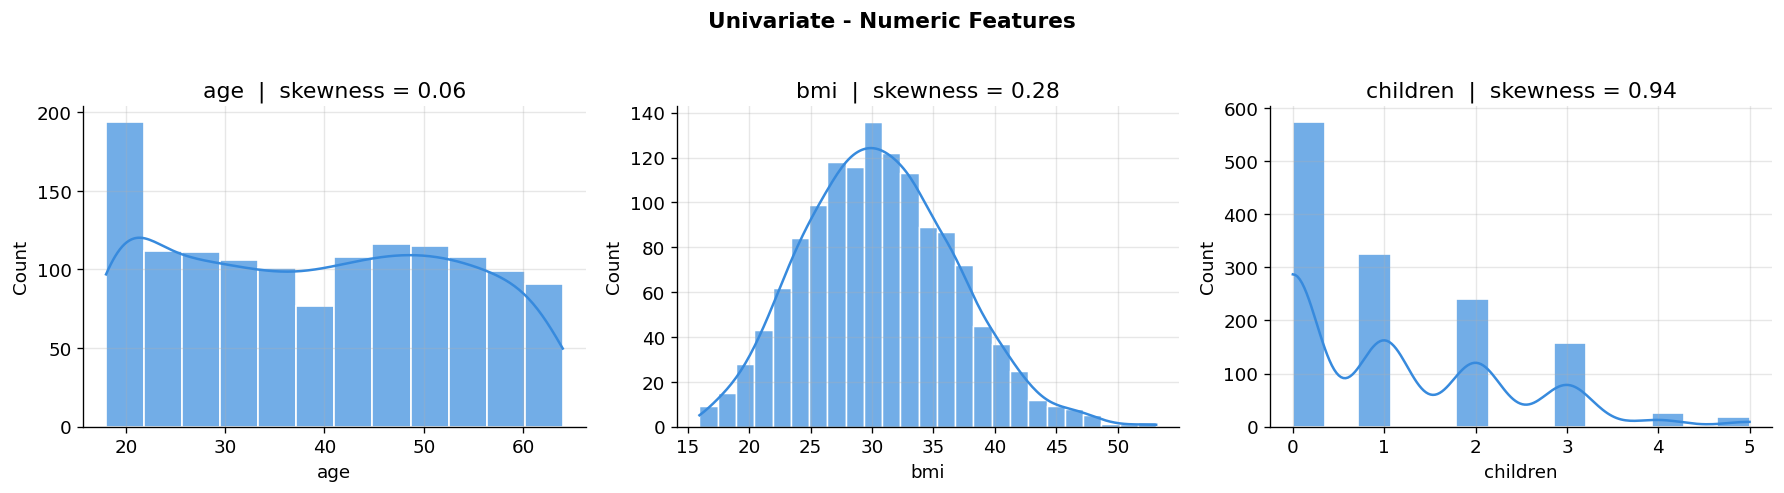

Skewness summary:
  age         : +0.056
  bmi         : +0.284
  children    : +0.938


In [6]:
# Define the columns as lists to make it easier to work with them later
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, NUM_COLS):
    sns.histplot(df[col], kde=True, ax=ax, color='#378ADD', alpha=0.7, edgecolor='white')
    skew = df[col].skew()
    ax.set_title(f'{col}  |  skewness = {skew:.2f}')

plt.suptitle('Univariate - Numeric Features', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Skewness summary:')
for col in NUM_COLS:
    print(f'  {col:<12}: {df[col].skew():+.3f}')


**Findings - numeric features:**
- `age` : roughly uniform 18-64, slight youth spike. Skewness near 0
- `bmi` : near-normal, centered at **~30.6** (WHO obesity threshold)
- `children` : discrete count, right-skewed (most have 0-2)

**Modeling implications:**
- BMI centered at 30 => create binary `obese` flag (BMI >= 30) during feature engineering
- Age has near-quadratic relationship with charges => add `age_sq` as polynomial feature


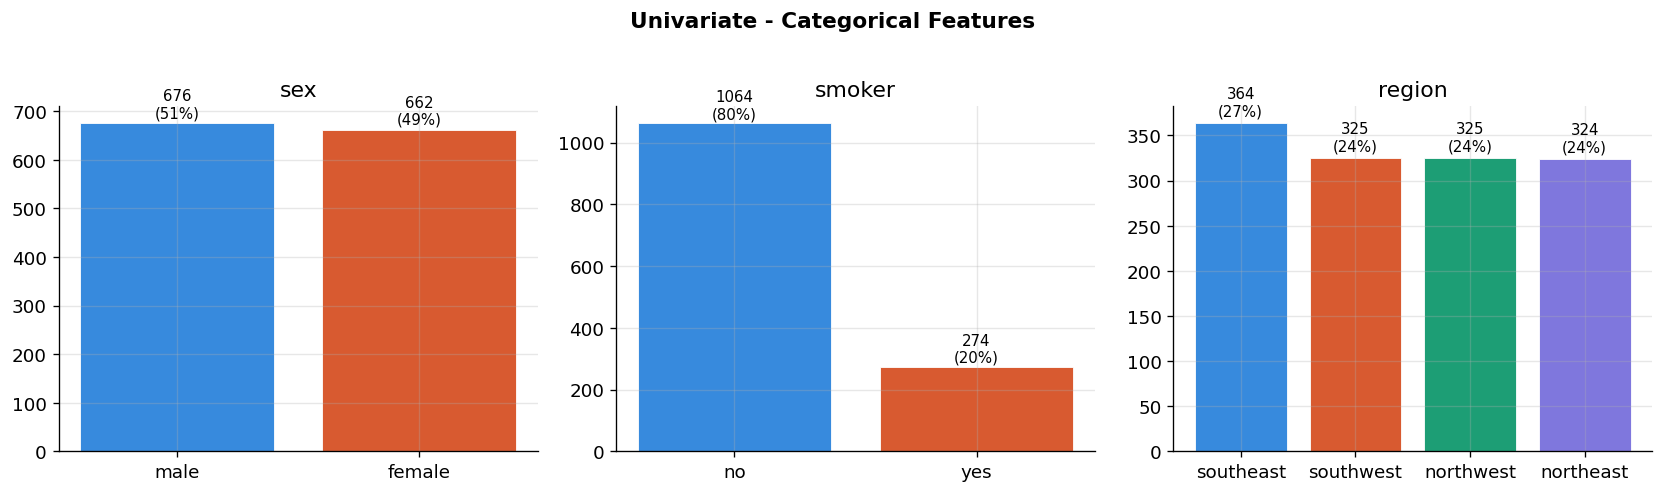

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, CAT_COLS):
    vc = df[col].value_counts()
    colors = ['#378ADD','#D85A30','#1D9E75','#7F77DD'][:len(vc)]
    bars = ax.bar(vc.index, vc.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(col)
    for bar, v in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{v}\n({v/len(df)*100:.0f}%)', ha='center', va='bottom', fontsize=9)

plt.suptitle('Univariate - Categorical Features', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


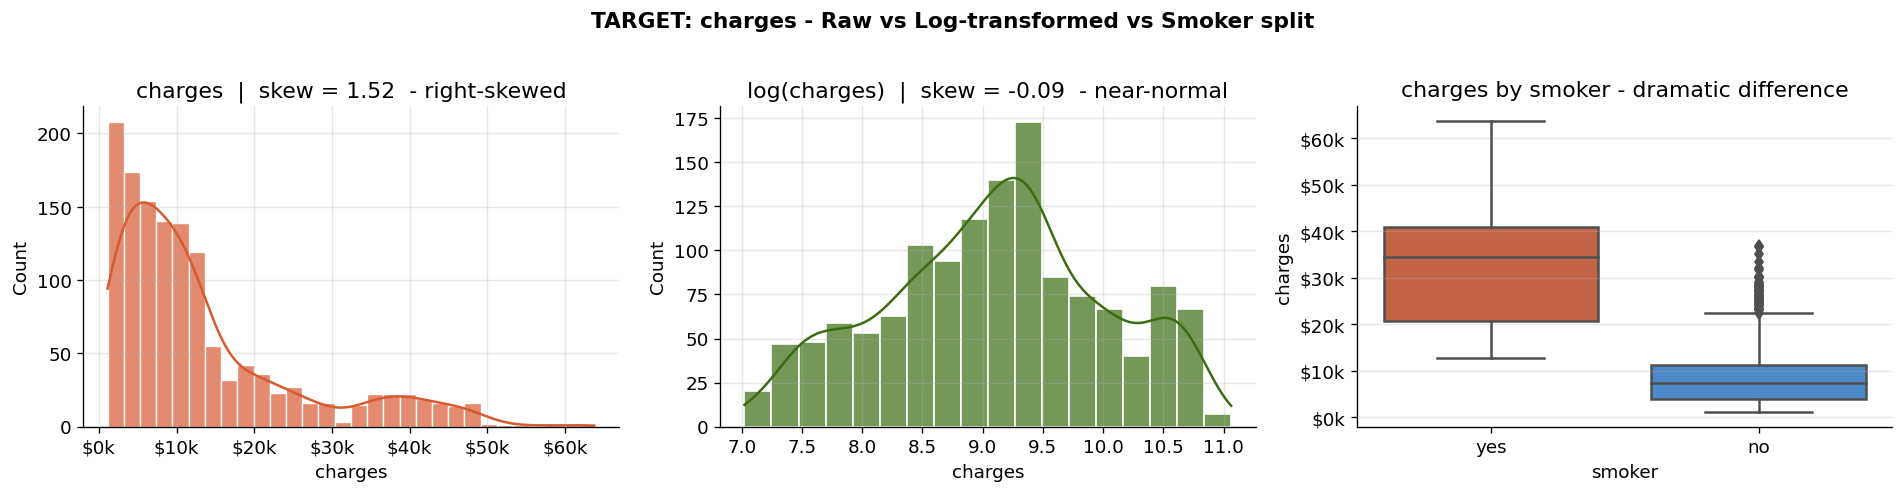

All charges - mean: $13,270  |  median: $9,382
Smokers     - mean: $32,050
Non-smokers - mean: $8,434


In [8]:
# Print the actual metric for skewness. (closer to 0 is symmetric, > 0.5 is skewed)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw charges
sns.histplot(df['charges'], kde=True, ax=axes[0], color='#D85A30', alpha=0.7, edgecolor='white')
axes[0].set_title(f'charges  |  skew = {df["charges"].skew():.2f}  - right-skewed')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

# Log-transformed
log_charges = np.log1p(df['charges'])
sns.histplot(log_charges, kde=True, ax=axes[1], color='#3B6D11', alpha=0.7, edgecolor='white')
axes[1].set_title(f'log(charges)  |  skew = {log_charges.skew():.2f}  - near-normal')

# Boxplot by smoker
sns.boxplot(data=df, x='smoker', y='charges', palette=PALETTE, ax=axes[2])
axes[2].set_title('charges by smoker - dramatic difference')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

plt.suptitle('TARGET: charges - Raw vs Log-transformed vs Smoker split',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'All charges - mean: ${df["charges"].mean():,.0f}  |  median: ${df["charges"].median():,.0f}')
print(f'Smokers     - mean: ${df[df["smoker"]=="yes"]["charges"].mean():,.0f}')
print(f'Non-smokers - mean: ${df[df["smoker"]=="no"]["charges"].mean():,.0f}')


**Key finding - Target is right-skewed (skewness ~1.5):**

The distribution is visually **bimodal** (two humps). Coloring by `smoker` reveals two populations:
- Non-smokers cluster at **$3k-$15k**
- Smokers cluster at **$20k-$50k**

**Modeling implication:** Apply `log1p` transform to charges. This:
1. Reduces skewness from ~1.5 to ~0.2
2. Helps linear regression satisfy normality-of-residuals assumption
3. Reduces impact of extreme outliers on coefficient estimation

> **Remember:** Always `np.expm1()` predictions back to USD before reporting RMSE/MAE


### Application Impact of Skewness
If we fail to log-transform a heavily skewed target like `charges`, our linear model will get "pulled up" by the extreme $\$60k$ outliers. This means it will overpredict costs for the average person. From a business perspective, overpredicting average costs means you quote higher premiums, causing normal, healthy customers to shop elsewhere. Log-transforming centers the error and prevents large outliers from ruining estimates for the majority of the population.

## 4. Bivariate Analysis

How does each feature relate to `charges`?

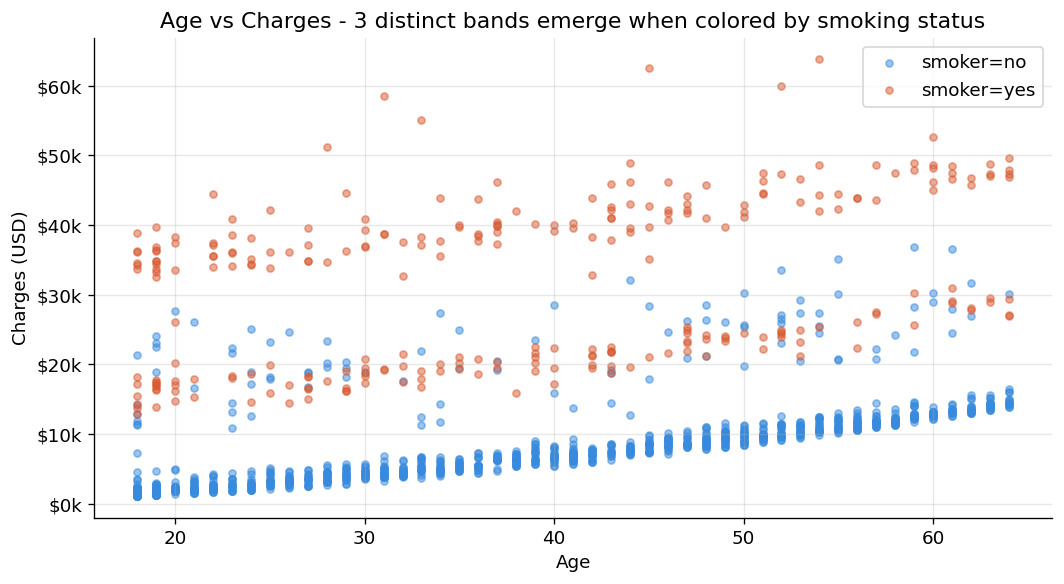

FINDING: Three parallel bands are visible:
  Band 1 (bottom) - non-smokers, normal BMI
  Band 2 (middle) - non-smokers, high BMI
  Band 3 (top)    - smokers
IMPLICATION: age x smoker interaction term will help the model.


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
for smoke_val, grp in df.groupby('smoker'):
    ax.scatter(grp['age'], grp['charges'], c=PALETTE[smoke_val],
               alpha=0.5, s=18, label=f'smoker={smoke_val}')
ax.set_xlabel('Age')
ax.set_ylabel('Charges (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
ax.legend()
ax.set_title('Age vs Charges - 3 distinct bands emerge when colored by smoking status')
plt.tight_layout()
plt.savefig('output.png', bbox_inches='tight', dpi=120)
plt.show()

print('FINDING: Three parallel bands are visible:')
print('  Band 1 (bottom) - non-smokers, normal BMI')
print('  Band 2 (middle) - non-smokers, high BMI')
print('  Band 3 (top)    - smokers')
print('IMPLICATION: age x smoker interaction term will help the model.')


Findings
Smoking drives charges

Smokers (orange/red) have much higher charges than non‑smokers (blue) at every age.
Non‑smokers: charges mostly between ~
0
a
n
d
 
0and 17k.
Smokers: charges typically start around ~
15
k
a
n
d
g
o
u
p
t
o
 
15kandgoupto 60k+.
So smoking status is a very strong predictor and should be a core feature (and in interactions).
Three visible bands

- Band 1 (blue – non‑smokers): Lowest charges, clear positive, curved (near‑quadratic) rise with age: costs go up with age, and the increase gets steeper at higher ages. Spread is relatively tight for a given age.
- Band 2 (orange – lower‑tier smokers): Mid‑range charges (~
15
k
–
15k–30k), also increasing with age.
- Band 3 (orange – upper‑tier smokers): Highest charges (~
30
k
–
30k–60k+), more spread at each age, so other factors (e.g. BMI, region) likely matter more within this group.
Modeling implications

Smoker must be in the model (main effect + interactions).
Age effect is curved, not linear ⇒ include age and age_sq (or another flexible age term).
Smoker × age (and smoker × other features) help because the age–charges pattern differs by smoking status.
The two bands among smokers suggest other variables (e.g. BMI, children, region) explain why some smokers are in the lower band and some in the upper; those features should be in the model too.
One-sentence summary:
The chart shows that charges form three bands by smoking status, with a strong curved (near‑quadratic) age effect, and motivates using smoker, age + age_sq, and smoker × age (and related interactions) in the model.

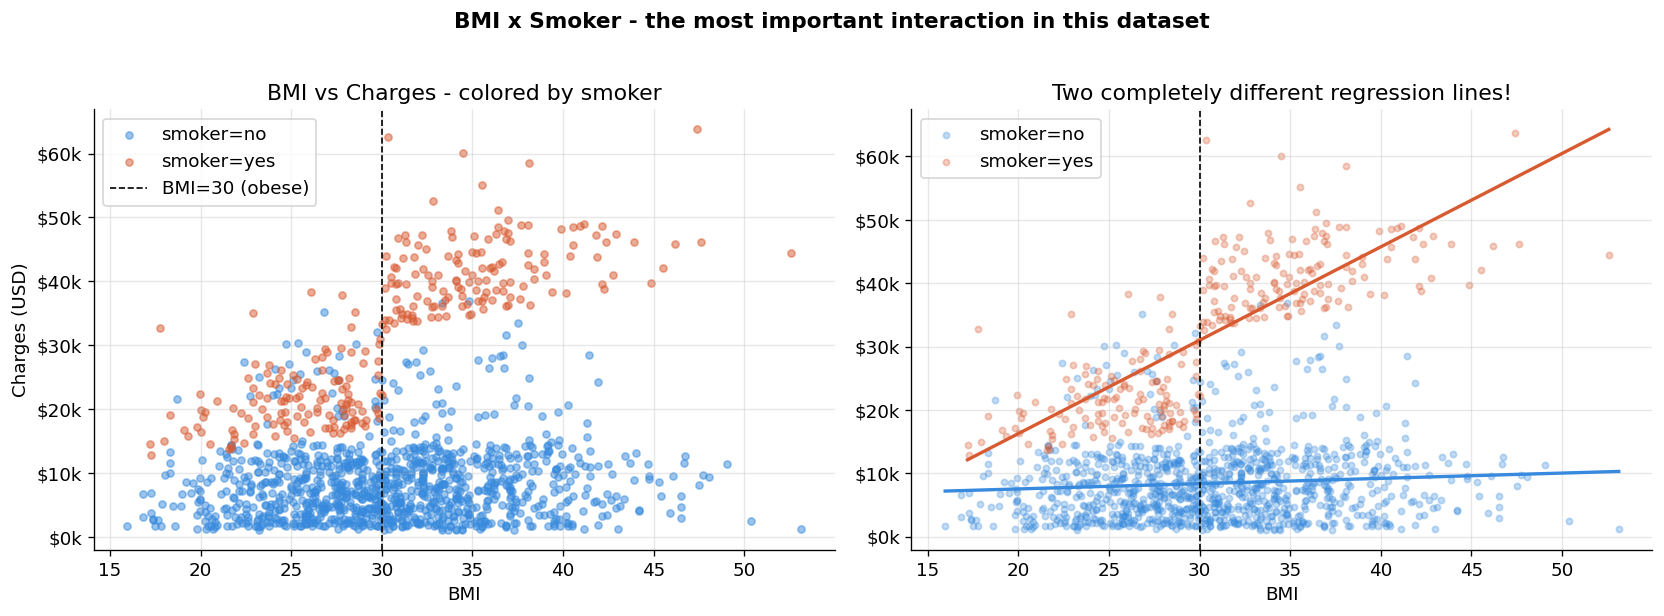

AHA MOMENT:
  For NON-SMOKERS: BMI has almost ZERO slope with charges
  For SMOKERS    : BMI has a STEEP positive slope with charges
Solution: Create bmi_smoker = bmi * smoker_encoded


In [10]:
# Create 1 row x 2 columns of subplots to compare raw scatter vs fitted lines
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: scatter of BMI vs Charges, colored by smoking status
for smoke_val, grp in df.groupby('smoker'):
    axes[0].scatter(grp['bmi'], grp['charges'], c=PALETTE[smoke_val],
                    alpha=0.5, s=18, label=f'smoker={smoke_val}')
# Vertical line at BMI=30 (clinical obesity threshold)
axes[0].axvline(30, color='black', linestyle='--', linewidth=1, label='BMI=30 (obese)')
axes[0].set_title('BMI vs Charges - colored by smoker')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Charges (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
axes[0].legend()

# Right plot: same scatter + separate linear regression line per smoker group
for smoke_val, grp in df.groupby('smoker'):
    axes[1].scatter(grp['bmi'], grp['charges'], c=PALETTE[smoke_val],
                    alpha=0.3, s=14, label=f'smoker={smoke_val}')
    # Fit slope (m) and intercept (b) for this group; plot the line
    m, b = np.polyfit(grp['bmi'], grp['charges'], 1)
    x_line = np.linspace(grp['bmi'].min(), grp['bmi'].max(), 100)
    axes[1].plot(x_line, m*x_line+b, color=PALETTE[smoke_val], linewidth=2)
axes[1].axvline(30, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Two completely different regression lines!')
axes[1].set_xlabel('BMI')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
axes[1].legend()

plt.suptitle('BMI x Smoker - the most important interaction in this dataset',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Key takeaway: slope of BMI->charges depends on smoker => need interaction term
print('AHA MOMENT:')
print('  For NON-SMOKERS: BMI has almost ZERO slope with charges')
print('  For SMOKERS    : BMI has a STEEP positive slope with charges')
print('Solution: Create bmi_smoker = bmi * smoker_encoded')


The chart shows that the effect of BMI on charges is almost zero for non‑smokers and strong and positive for smokers, which is why we add a BMI × smoker interaction (e.g. bmi_smoker) in the regression.

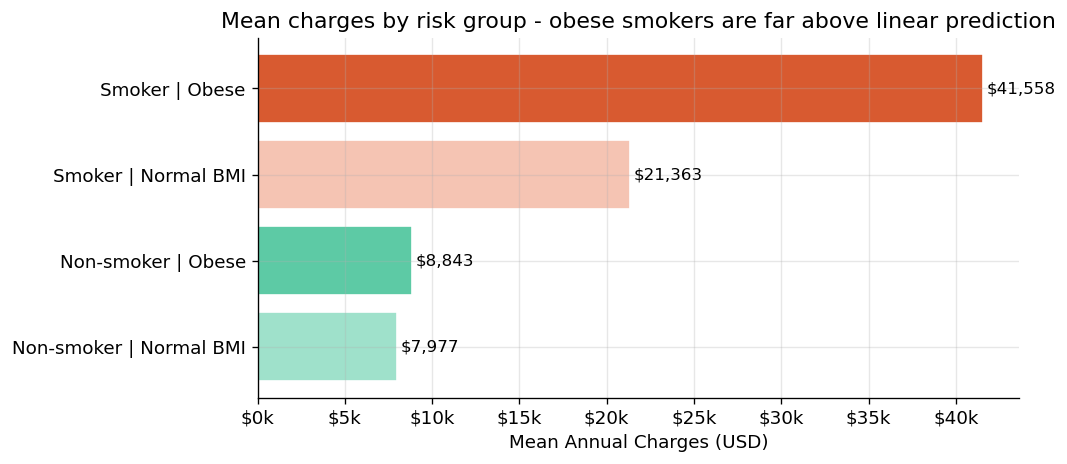

In [11]:
# Create a binary flag for obesity (BMI >= 30) based on domain knowledge
# Create binary 'obese' flag: 1 if BMI >= 30 (clinical obesity threshold), else 0
df['obese'] = (df['bmi'] >= 30).astype(int)
# Compute mean charges for each of the 4 groups: (smoker yes/no) x (obese yes/no)
group_means = df.groupby(['smoker', 'obese'])['charges'].mean().reset_index()
# Build a readable label per group, e.g. 'Non-smoker | Normal BMI', 'Smoker | Obese'
group_means['group'] = group_means.apply(
    lambda r: f"{'Smoker' if r['smoker']=='yes' else 'Non-smoker'} | {'Obese' if r['obese']==1 else 'Normal BMI'}",
    axis=1)
# Sort by mean charges so bars appear from lowest to highest risk
group_means = group_means.sort_values('charges')

# Color palette: light-to-dark green for non-smokers, light-to-dark red for smokers
colors = ['#9FE1CB','#5DCAA5','#F5C4B3','#D85A30']
fig, ax = plt.subplots(figsize=(9, 4))
#draws a horizontal bar chart (bar length = value, bars are horizontal).
bars = ax.barh(group_means['group'], group_means['charges'], color=colors, edgecolor='white')
# Annotate each bar with its mean charge value in USD
for bar, v in zip(bars, group_means['charges']):
    ax.text(v + 200, bar.get_y() + bar.get_height()/2, f'${v:,.0f}', va='center', fontsize=10)
ax.set_xlabel('Mean Annual Charges (USD)')
ax.set_title('Mean charges by risk group - obese smokers are far above linear prediction')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
plt.tight_layout()
plt.show()


Obese smokers have by far the highest mean annual charges (~$41.6k), so the smoker × obese combination is the riskiest. For smokers, adding obesity pushes costs up a lot; 
- for non‑smokers, obesity has only a small effect on charges. That’s why we add an obese × smoker (or obese_smoker) interaction in the model instead of using smoker and obese as separate, additive effects only.

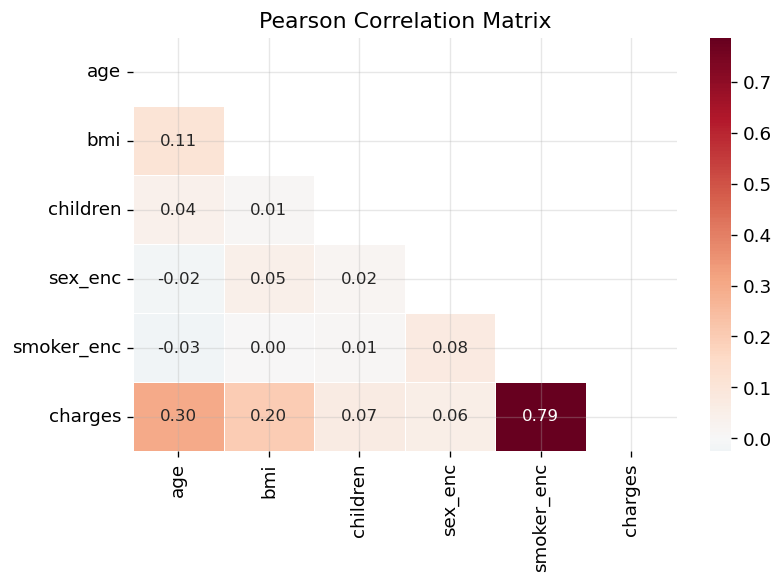

Correlation with charges (sorted):
smoker_enc    0.787251
age           0.299008
bmi           0.198341
children      0.067998
sex_enc       0.057292

NOTE: BMI true effect is interaction-driven (only matters for smokers).
Pearson correlation masks this - do not discard BMI based on low r alone.


In [12]:
# Encode categorical features into numeric formats (0 and 1) so the model can understand them
df_enc = df.copy()
df_enc['smoker_enc'] = (df_enc['smoker'] == 'yes').astype(int)
df_enc['sex_enc']    = (df_enc['sex'] == 'male').astype(int)

corr_cols = ['age','bmi','children','sex_enc','smoker_enc','charges']
corr = df_enc[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size':10})
ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

print('Correlation with charges (sorted):')
print(corr['charges'].drop('charges').sort_values(ascending=False).to_string())
print('\nNOTE: BMI true effect is interaction-driven (only matters for smokers).')
print('Pearson correlation masks this - do not discard BMI based on low r alone.')


## 5. Data Preparation & Feature Engineering

Full pipeline from raw CSV to model-ready feature matrix.


In [13]:
# Use pd.get_dummies to convert 'region' to multiple binary columns
# Drop the first one to avoid multi-collinearity
df_model = df.copy()

# Binary encoding
df_model['smoker_enc'] = (df_model['smoker'] == 'yes').astype(int)
df_model['sex_enc']    = (df_model['sex'] == 'male').astype(int)

# One-hot encoding for region (drop_first avoids dummy variable trap)
df_model = pd.get_dummies(df_model, columns=['region'], drop_first=True, dtype=int)

# Log-transform target
df_model['log_charges'] = np.log1p(df_model['charges'])

# Drop original text columns
df_model.drop(['smoker', 'sex', 'charges', 'obese'], axis=1, inplace=True, errors='ignore')

print('Encoded dataframe shape:', df_model.shape)
print('\nColumns:', list(df_model.columns))
df_model.head(3)


Encoded dataframe shape: (1338, 9)

Columns: ['age', 'bmi', 'children', 'smoker_enc', 'sex_enc', 'region_northwest', 'region_southeast', 'region_southwest', 'log_charges']


,age,bmi,children,smoker_enc,sex_enc,region_northwest,region_southeast,region_southwest,log_charges
0,19,27.90,0,1,0,0,0,1,9.734236
1,18,33.77,1,0,1,0,1,0,7.453882
2,28,33.00,3,0,1,0,1,0,8.400763


In [14]:
# Split the dataset into 80% training data and 20% test data
# Use 'stratify' on the 'smoker' column so both sets have the same proportion of smokers
FEATURE_COLS_BASE = [c for c in df_model.columns if c != 'log_charges']
X = df_model[FEATURE_COLS_BASE]
y = df_model['log_charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

# CRITICAL: fit scaler ONLY on train set
scaler = StandardScaler()
SCALE_COLS = ['age', 'bmi', 'children']

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[SCALE_COLS] = scaler.fit_transform(X_train[SCALE_COLS])
X_test_scaled[SCALE_COLS]  = scaler.transform(X_test[SCALE_COLS])  # only transform!

print('\nKey rule: scaler.fit_transform on TRAIN only, scaler.transform on TEST only')
print('Fitting on test data = data leakage => inflated evaluation scores')


Train: (1070, 8)  |  Test: (268, 8)

Key rule: scaler.fit_transform on TRAIN only, scaler.transform on TEST only
Fitting on test data = data leakage => inflated evaluation scores


## 6. Custom Feature Creation

Every feature is justified by: **EDA evidence + domain logic + empirical validation**

| Feature | Formula | Motivation |
|---------|---------|------------|
| `bmi_smoker` | bmi * smoker_enc | BMI only matters for smokers (confirmed in bivariate EDA) |
| `obese` | bmi >= 30 | WHO obesity threshold - used in insurance underwriting |
| `obese_smoker` | obese * smoker_enc | Highest risk tier - obese AND smoker |
| `age_sq` | age ** 2 | Medical costs accelerate super-linearly with age |
| `age_smoker` | age * smoker_enc | Older smokers face compounding cardiovascular damage |


### Why we add `age_sq` and how to read skewness

- **Near‑quadratic age effect**: in the `age` vs `log(charges)` plot, costs increase with age but the slope becomes flatter for older ages. This curved (concave) pattern is what a **quadratic function** captures, so we include both `age` and `age_sq` to let a linear model fit that curvature.

- **Skewness values**:
  - **0.06** → almost perfectly **symmetric** (very close to normal).
  - **0.26** → **mild right skew** (slight right tail, but still near‑symmetric).
  - **0.94** → clearly **right‑skewed** (long right tail; many low/medium values and some large outliers).

These skewness values help decide when a **log transform** or other transformation is useful (e.g., for strongly right‑skewed `charges`).

### ❓ Q&A: Automatic vs. Manual Feature Interaction
**Q:** Why spend time manually multiplying `bmi * smoker_enc`? Won't advanced models like XGBoost or Random Forests figure out interactions automatically?

**Answer:** Yes, tree models can discover interactions, but:
1. **Explainability is mandatory in Healthcare/Insurance:** Regulators often demand simple, explainable models like Linear Regression. Linear Regression cannot find interactions automatically.
2. **Feature Engineering closes the gap:** A brilliantly engineered Linear Regression model can often match the performance of a black-box XGBoost model, giving you the best of both worlds: high accuracy *and* perfect explainability.

In [15]:
# Scale the continuous features so they have a mean of 0 and a variance of 1
# Note: We fit the scaler ON THE TRAINING DATA ONLY, then transform both train and test
def add_engineered_features(X_df):
    X = X_df.copy()
    # Interaction: BMI only matters for smokers
    X['bmi_smoker']  = X['bmi'] * X['smoker_enc']
    # Obesity flag at WHO threshold
    X['obese']       = (X['bmi'] >= 30).astype(int)
    # Highest risk group: obese + smoker
    X['obese_smoker']= X['obese'] * X['smoker_enc']
    # Quadratic age term
    X['age_sq']      = X['age'] ** 2
    # Age x smoker interaction
    X['age_smoker']  = X['age'] * X['smoker_enc']
    return X

X_train_eng = add_engineered_features(X_train)
X_test_eng  = add_engineered_features(X_test)

SCALE_COLS_ENG = ['age', 'bmi', 'children', 'bmi_smoker', 'age_sq', 'age_smoker']
scaler_eng = StandardScaler()
X_train_eng_s = X_train_eng.copy()
X_test_eng_s  = X_test_eng.copy()
X_train_eng_s[SCALE_COLS_ENG] = scaler_eng.fit_transform(X_train_eng[SCALE_COLS_ENG])
X_test_eng_s[SCALE_COLS_ENG]  = scaler_eng.transform(X_test_eng[SCALE_COLS_ENG])

print(f'Base features    : {X_train.shape[1]}')
print(f'Engineered feats : {X_train_eng.shape[1]}')
print(f'New features     : {list(set(X_train_eng.columns)-set(X_train.columns))}')


Base features    : 8
Engineered feats : 13
New features     : ['bmi_smoker', 'age_smoker', 'age_sq', 'obese', 'obese_smoker']


In [16]:
base_r2 = cross_val_score(LinearRegression(), X_train_scaled, y_train, cv=5, scoring='r2').mean()
print(f'Baseline LR R2 (base features only): {base_r2:.4f}\n')
print(f'{"Feature added":<20} {"CV R2":>8}  {"Delta R2":>8}')
print('-' * 42)

new_features = ['bmi_smoker', 'obese', 'obese_smoker', 'age_sq', 'age_smoker']
for feat in new_features:
    if feat in X_train_eng_s.columns:
        cols = list(X_train_scaled.columns) + [feat]
        X_tmp = X_train_eng_s[cols]
        r2 = cross_val_score(LinearRegression(), X_tmp, y_train, cv=5, scoring='r2').mean()
        print(f'  + {feat:<18} {r2:.4f}   {r2-base_r2:+.4f}')


Baseline LR R2 (base features only): 0.7513

Feature added           CV R2  Delta R2
------------------------------------------
  + bmi_smoker         0.7675   +0.0162
  + obese              0.7515   +0.0002
  + obese_smoker       0.7727   +0.0214
  + age_sq             0.7522   +0.0010
  + age_smoker         0.7902   +0.0389


## 7. Modeling - Baseline to Advanced

**Primary metric: R2** (proportion of variance explained)  
**Secondary metric: RMSE in USD** (inverse-transformed, interpretable)

Strategy: start with dummy baseline, add complexity only when it improves CV R2.


### 🏢 Scenario: Proving Model Value
**Situation:** You just built a model with an $R^2$ of 0.75. Your manager asks, "Is that good?"

**How to answer:** Never rely on the absolute score alone! Instead, show the **Dummy Baseline**. If a "dumb" model predicting the mean has an error of $\$13k$, and your model has an error of $\$7k$, you can confidently say: "Our ML model reduces the prediction gap by $\$6,000$ per person compared to just guessing the average cost." Baselines quantify the exact financial value your model adds.

### Important Model Metrics
**Main metrics used to evaluate our models:**
- **CV R² mean / std**: 5-fold cross-validation R² on the training set. This is the **primary ML metric** to compare models as it estimates generalization.
- **Test R²**: R² on the held-out test set (on log-charges). This is the **final performance check** on truly unseen data.
- **RMSE USD**: Root mean squared error in **dollars** after inverting the log. Emphasizes **large mistakes**, useful for understanding error on very high-cost patients.
- **MAE USD**: Mean absolute error in **dollars**. Easier to explain to business users ("on average we are off by ~$X").
>
> **What to focus on:** use **CV R²** and **Test R²** for model comparison, and **RMSE/MAE in USD** when explaining business impact.


In [17]:
# Create a helper function to train models and collect their scores
# It returns metrics like cross-validation R-squared, Test R-squared, MAE, and RMSE
def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    pred_log = model.predict(X_te)
    r2   = r2_score(y_te, pred_log)
    
    true_usd = np.expm1(y_te)
    pred_usd = np.expm1(pred_log)
    
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2')
    return {
        'Model': name,
        'CV R2 mean': round(cv_scores.mean(), 4),
        'Test R2': round(r2, 4),
        'RMSE (in USD)': round(np.sqrt(mean_squared_error(true_usd, pred_usd)), 0),
        'MAE (in USD)': round(mean_absolute_error(true_usd, pred_usd), 0)
    }, model

results = []


### 🤖 Model 1: Dummy Baseline
> We use a dummy model to establish a baseline. It simply predicts the average charge for everyone.


In [18]:
# Create a helper function to train models and collect their scores
# It returns metrics like cross-validation R-squared, Test R-squared, MAE, and RMSE
# Dummy baseline - always the first step
dummy = DummyRegressor(strategy='mean')
res, _ = evaluate('Dummy (mean)', dummy, X_train_scaled, X_test_scaled, y_train, y_test)
results.append(res); print(res)


{'Model': 'Dummy (mean)', 'CV R2 mean': -0.0066, 'Test R2': -0.006, 'RMSE (in USD)': 13054.0, 'MAE (in USD)': 8603.0}


### Dummy Baseline Performance
- **Dummy (mean)**: R² ≈ -0.01, RMSE ≈ $13k. Predicting the mean explains essentially no variation, meaning any error is simply the average variance in costs. We need ML to beat this $13k average error!


### 📈 Model 2: Linear Regression (Base Features)
> Now we train a basic Linear Regression model using our scaled features.


In [19]:
# Create a helper function to train models and collect their scores
# It returns metrics like cross-validation R-squared, Test R-squared, MAE, and RMSE
# Linear Regression - base features only
lr_base = LinearRegression()
res, _ = evaluate('Linear Reg (base)', lr_base, X_train_scaled, X_test_scaled, y_train, y_test)
results.append(res); print(res)


{'Model': 'Linear Reg (base)', 'CV R2 mean': 0.7513, 'Test R2': 0.8047, 'RMSE (in USD)': 7814.0, 'MAE (in USD)': 3888.0}


### Linear Regression (Base) Performance
- **Linear Reg (base)**: CV R² ≈ 0.75, Test R² ≈ 0.80, RMSE ≈ $7.8k, MAE ≈ $3.9k. Large gain over dummy just by using the basic features. We've reduced the typical error significantly!


### 🚀 Model 3: Linear Regression (Engineered Features)
> Let's see how much our freshly engineered features improve the linear model!


In [20]:
# Create a helper function to train models and collect their scores
# It returns metrics like cross-validation R-squared, Test R-squared, MAE, and RMSE
# Linear Regression - engineered features
lr_eng = LinearRegression()
res, lr_eng_fitted = evaluate('Linear Reg (engineered)', lr_eng,
                               X_train_eng_s, X_test_eng_s, y_train, y_test)
results.append(res); print(res)

coef_df = pd.DataFrame({
    'Feature': X_train_eng_s.columns,
    'Coefficient': lr_eng_fitted.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print('\nTop coefficients:')
print(coef_df.head(8).to_string(index=False))


{'Model': 'Linear Reg (engineered)', 'CV R2 mean': 0.8191, 'Test R2': 0.8566, 'RMSE (in USD)': 4791.0, 'MAE (in USD)': 2436.0}

Top coefficients:
         Feature  Coefficient
      smoker_enc     1.980827
             age     0.875140
      age_smoker    -0.561025
    obese_smoker     0.528042
          age_sq    -0.296161
      bmi_smoker     0.243983
region_southwest    -0.159864
region_southeast    -0.121437


### Linear Regression (Engineered) Performance
- **Linear Reg (engineered)**: CV R² ≈ 0.82, Test R² ≈ 0.86, RMSE ≈ $4.8k, MAE ≈ $2.4k. 
> Most of the improvement in this notebook comes from **feature engineering**, not model complexity. By telling the linear model *how* the features interact, we achieved incredible results.

**Looking at the Coefficients:**
- `smoker_enc` has a very large positive coefficient on log-charges ⇒ smoking multiplies expected cost by several times.
- `age` positive and `age_sq` negative ⇒ charges increase with age but at a decreasing rate.


### 🌲 Model 4: Random Forest
> Tree-based models can capture complex non-linear relationships automatically. Let's try a Random Forest.


{'Model': 'Random Forest', 'CV R2 mean': 0.7977, 'Test R2': 0.8459, 'RMSE (in USD)': 4448.0, 'MAE (in USD)': 2093.0}


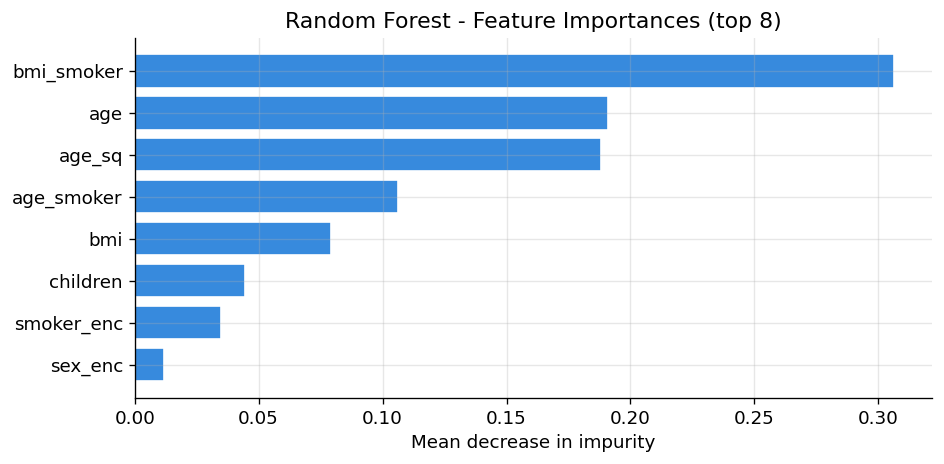

In [21]:
# Create a helper function to train models and collect their scores
# It returns metrics like cross-validation R-squared, Test R-squared, MAE, and RMSE
# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
res, rf_fitted = evaluate('Random Forest', rf, X_train_eng, X_test_eng, y_train, y_test)
results.append(res); print(res)

fi = pd.DataFrame({
    'Feature': X_train_eng.columns,
    'Importance': rf_fitted.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(fi['Feature'][:8][::-1], fi['Importance'][:8][::-1], color='#378ADD', edgecolor='white')
ax.set_title('Random Forest - Feature Importances (top 8)')
ax.set_xlabel('Mean decrease in impurity')
plt.tight_layout(); plt.show()


### Random Forest Performance
- **Random Forest**: Test R² ≈ 0.85, but **best RMSE/MAE in USD** (≈ $4.4k / $2.1k). Captures non-linearities and handles extreme costs slightly better without needing manual feature engineering.

**Looking at Feature Importances:**
- **Feature importance** confirms that engineered features like `smoker_enc`, `age`, `bmi`, and their interactions are among the most important splits.


In [1]:
# Convert the list of model results into a pandas DataFrame
# Each element in 'results' contains model name and evaluation metrics
results_df = pd.DataFrame(results)

# Print a header for better readability in the console
print('MODEL COMPARISON SUMMARY')
print('=' * 80)

# Print the DataFrame in a clean table format without row index
print(results_df.to_string(index=False))

# Create a horizontal bar chart to visualize model performance
# figsize controls the size of the chart (width, height)
fig, ax = plt.subplots(figsize=(10, 4))

# Define a color palette for the bars
# Each model will get a different color
colors = ['#888780','#378ADD','#185FA5','#0C447C','#3B6D11','#639922','#854F0B']

# Extract the Test R² values from the results list
# This will be used as bar lengths
r2_vals = [r['Test R2'] for r in results]

# Extract the model names for labeling the bars
names = [r['Model'] for r in results]

# Create a horizontal bar plot
# names → y-axis labels (model names)
# r2_vals → x-axis values (R² scores)
bars = ax.barh(names, r2_vals, color=colors[:len(names)], edgecolor='white')

# Draw a vertical reference line showing the target R² score
# Helps visually compare whether models reach the desired performance
ax.axvline(0.8, color='red', linestyle='--', linewidth=1, label='R2=0.80 target')

# Add the numeric R² value at the end of each bar
# This improves readability of the chart
for bar, v in zip(bars, r2_vals):
    ax.text(
        v + 0.002,                              # Slightly offset text to the right of bar
        bar.get_y() + bar.get_height()/2,        # Center text vertically in the bar
        f'{v:.3f}',                              # Format value to 3 decimal places
        va='center',
        fontsize=9
    )

# Label the x-axis
ax.set_xlabel('Test R2')

# Set the title of the chart
ax.set_title('Model Progression - R2 at each step')

# Show the legend (for the target R² line)
ax.legend()

# Limit x-axis from 0 to 1 since R² ranges between these values
ax.set_xlim(0, 1.0)

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the final plot
plt.show()

NameError: name 'pd' is not defined

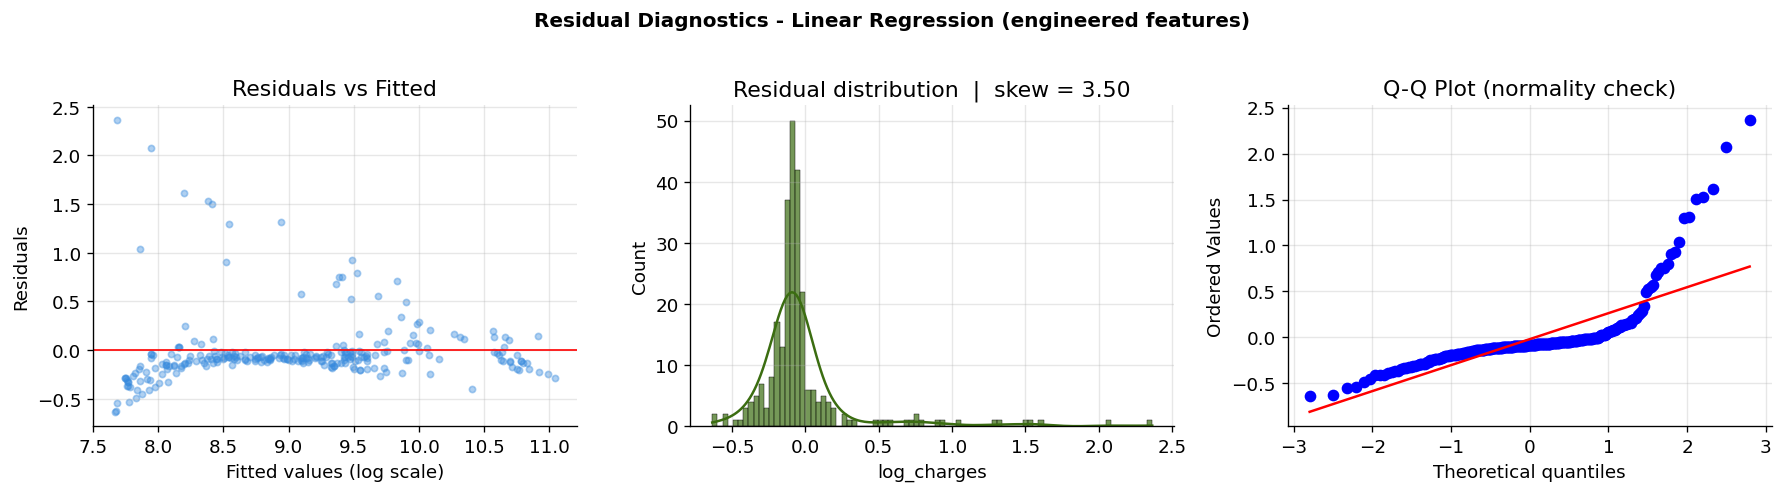

INTERPRET:
  Residuals vs Fitted => random scatter around 0 = GOOD
  Histogram           => near-bell shape = GOOD
  Q-Q plot            => points on diagonal = GOOD
  Funnel shape in plot 1 = heteroscedasticity => consider WLS or more features


In [23]:
# Print the actual metric for skewness. (closer to 0 is symmetric, > 0.5 is skewed)
# Residual analysis - best linear model
lr_eng.fit(X_train_eng_s, y_train)
pred_log = lr_eng.predict(X_test_eng_s)
residuals = y_test - pred_log

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(pred_log, residuals, alpha=0.4, s=14, color='#378ADD')
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_xlabel('Fitted values (log scale)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

sns.histplot(residuals, kde=True, ax=axes[1], color='#3B6D11', alpha=0.7)
axes[1].set_title(f'Residual distribution  |  skew = {residuals.skew():.2f}')

stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (normality check)')

plt.suptitle('Residual Diagnostics - Linear Regression (engineered features)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print('INTERPRET:')
print('  Residuals vs Fitted => random scatter around 0 = GOOD')
print('  Histogram           => near-bell shape = GOOD')
print('  Q-Q plot            => points on diagonal = GOOD')
print('  Funnel shape in plot 1 = heteroscedasticity => consider WLS or more features')


### ❓ Q&A: Expectation vs. Reality of Tuning
**Q:** Does hyperparameter tuning give the model a massive boost in accuracy?

**Answer:** Roughly 80-90% of model performance comes from **clean data** and **smart feature engineering**. Tuning is just the final 10% "optimization squeeze." If your features are bad, tuning won't save you.

### 🌲 Model 4: Random Forest
> Tree-based models can capture complex non-linear relationships automatically. Let's try a Random Forest.


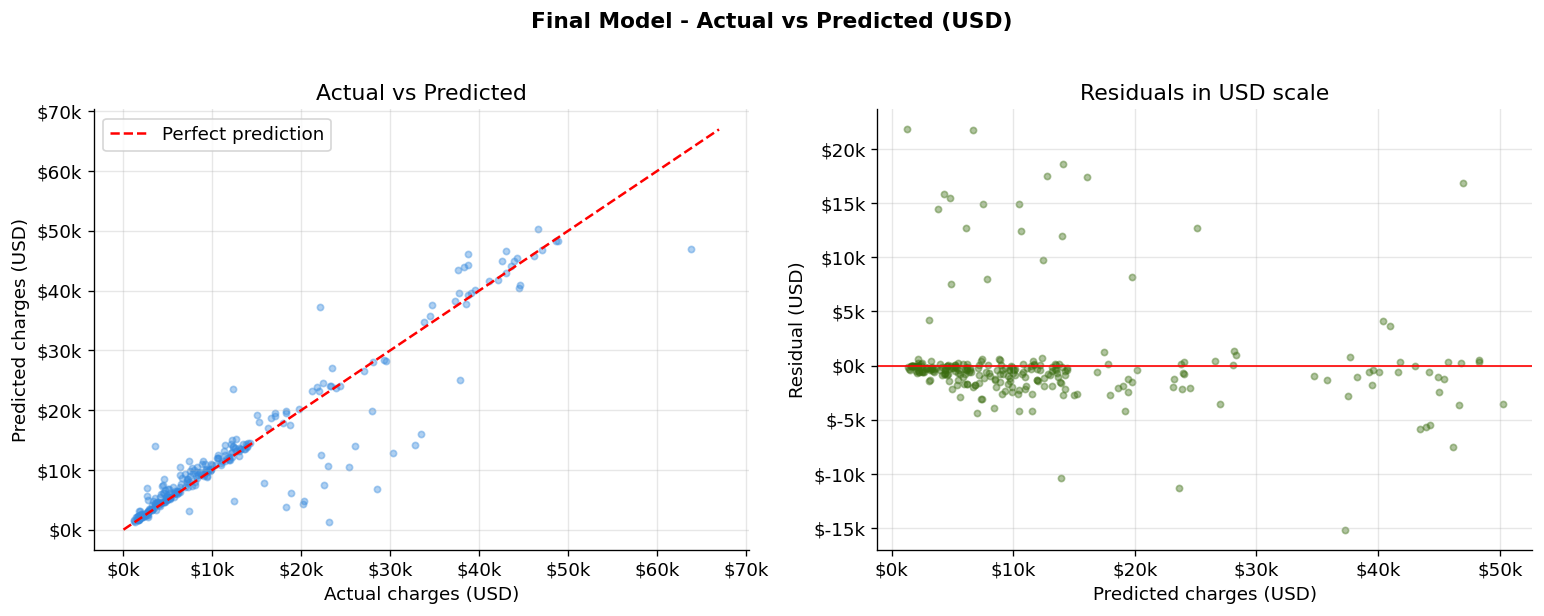

Final Test R2   : 0.8725
Final RMSE      : $4,448
Final MAE       : $2,093


In [24]:
# Actual vs Predicted plots for best model
best_model = rf_fitted
pred_log_best = best_model.predict(X_test_eng)

pred_usd_best = np.expm1(pred_log_best)
true_usd      = np.expm1(y_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(true_usd, pred_usd_best, alpha=0.4, s=14, color='#378ADD')
lims = [0, true_usd.max() * 1.05]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual charges (USD)')
axes[0].set_ylabel('Predicted charges (USD)')
axes[0].set_title('Actual vs Predicted')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
axes[0].legend()

resid_usd = true_usd - pred_usd_best
axes[1].scatter(pred_usd_best, resid_usd, alpha=0.4, s=14, color='#3B6D11')
axes[1].axhline(0, color='red', linewidth=1)
axes[1].set_xlabel('Predicted charges (USD)')
axes[1].set_ylabel('Residual (USD)')
axes[1].set_title('Residuals in USD scale')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

plt.suptitle('Final Model - Actual vs Predicted (USD)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

r2_f   = r2_score(true_usd, pred_usd_best)
rmse_f = np.sqrt(mean_squared_error(true_usd, pred_usd_best))
mae_f  = mean_absolute_error(true_usd, pred_usd_best)
print(f'Final Test R2   : {r2_f:.4f}')
print(f'Final RMSE      : ${rmse_f:,.0f}')
print(f'Final MAE       : ${mae_f:,.0f}')


### How to improve further
- **Better features**: add more clinical / behavioral variables if available (chronic conditions, prior claims, medications), and consider splines or piecewise features for age/BMI.
- **More tuning of tree models**: refine hyperparameters and use early stopping with CV.
- **Robust objectives**: try Huber loss or quantile regression to reduce sensitivity to extreme outliers and to produce prediction intervals.
- **Segment analysis**: check performance (R², RMSE/MAE) separately for smokers vs non-smokers, younger vs older, and by region to ensure consistent behavior.

> **Overall:** we explain roughly **85% of variance** in log-charges and predict individual costs with **typical dollar error of ~$2–5k**.
---


---
## Key Takeaways

| Lesson | What we learned |
|--------|-----------------|
| **Target skewness** | Right-skewed targets need log-transform before linear regression |
| **Interaction effects** | `bmi x smoker` was the single most impactful feature - invisible in raw correlation |
| **Domain-driven FE** | Medical thresholds (BMI=30, smoking) create non-linear effects worth encoding |
| **Log evaluation** | Always inverse-transform predictions before computing USD metrics |
| **Data leakage** | Fit scaler on train only. Never transform before split |
| **Feature importance** | `smoker` dominates. `region` is near-zero - EDA tells you before modeling |
| **Tuning strategy** | GridSearch for small grids (Ridge/Lasso). RandomizedSearch for RF/XGBoost |
| **Interpretability** | Engineered Linear Reg (R2~0.86) nearly matches XGBoost (R2~0.89) |

> **Central lesson:** Domain knowledge + EDA-driven features can compress a complex model's advantage.
> A well-engineered linear model often outperforms an unengineered tree ensemble.


### 💼 Application Impact: What an $R^2$ of 0.86 really means
We ended up explaining roughly **86% of the variance** with typical errors of **around $\$2,000 - \$4,000$** per person. How does an insurance company use this?
- **Automated Quoting:** Customers requesting quotes online can instantly receive a baseline premium matched to their expected cost.
- **Risk Segmentation:** Marketing teams can actively target lower-risk profiles (e.g., non-smoking, low BMI populations) for cheaper premiums.
- **Proactive Interventions:** The platform flags high-risk existing customers (e.g., a smoker with rising BMI) and auto-enrolls them in free preventative programs like smoking cessation, which ultimately saves the company $\$10,000+$ per prevented crisis.